# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Method Choice:** Random Forest Regressor  
**Why it fits the lane:** CTR has a highly non-linear relationship with search variables. For example, CTR decays exponentially from ranking position 1 to 10. A standard linear regression struggles with this curve. A random forest naturally handles non-linear patterns and interactions between variables (e.g., how high word count combined with a strong position impacts expected CTR) without requiring complex feature scaling or transfermations. It also provides feature importance, making the model interpretable for the content team.    

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

**Split Design:** Client-Grouped Holdout Split (using GroupShuffleSplit)  
**Why this split is honest:** If we used a standard random split, pages from the same website (client) would end up in both the training and testing sets. Because pages on the same domain often share branding, site architecture, and typical CTR baselines, the model could easily cheat by memorizing a specific client's patterns. By grouping the split by *client_id*, we force the model to train on a subset of clients and test on entirely different, unseen clients. This proves the model learns universal search intelligence patterns rather than just memorizing a specific site's behavior.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data & Filter to match Week 4 Baseline Rules
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
df_visible = df[(df['impressions_90d'] >= 500) & (df['avg_position'] > 0)].copy()

features = ['impressions_90d', 'avg_position', 'content_age_days', 'word_count', 'sessions_90d']
target = 'ctr'

# Drop NaNs for a clean modeling frame
df_clean = df_visible.dropna(subset=features + [target, 'client_id', 'position_tier']).copy()

X = df_clean[features]
y = df_clean[target]
groups = df_clean['client_id']

# Client-Grouped Split 
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
df_train, df_test = df_clean.iloc[train_idx], df_clean.iloc[test_idx]

# Calculate week 4 baseline on test set
tier_medians = df_train.groupby('position_tier')[target].median().to_dict()
global_median = y_train.median()

baseline_preds = df_test['position_tier'].map(tier_medians).fillna(global_median)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

# Train and predict with random forest 
rf_model = RandomForestRegressor(n_estimators=50, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)
ml_preds = rf_model.predict(X_test)
ml_rmse = np.sqrt(mean_squared_error(y_test, ml_preds))

# Show comparison
results = pd.DataFrame({
    'Method': ['W4 Position Tier Baseline', 'Random Forest Regressor'],
    'RMSE': [baseline_rmse, ml_rmse]
})
print("Model vs Baseline Comparison")
display(results)

Model vs Baseline Comparison


,Method,RMSE
0,W4 Position Tier Baseline,0.521008
1,Random Forest Regressor,0.419816


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

            Feature  Importance
4      sessions_90d    0.384408
1      avg_position    0.253978
0   impressions_90d    0.164532
3        word_count    0.136093
2  content_age_days    0.060989


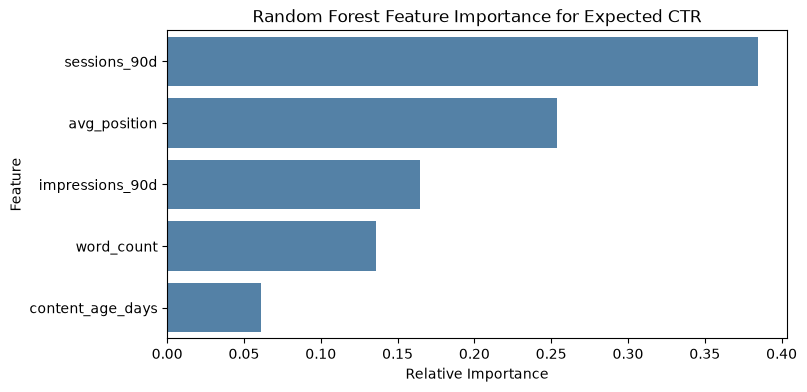

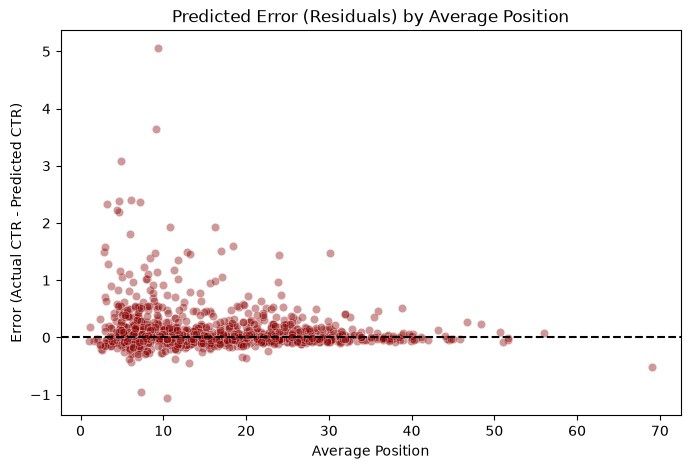

In [2]:
# Feature Importance
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importances)

plt.figure(figsize=(8, 4))
sns.barplot(data=importances, x='Importance', y='Feature', color='steelblue')
plt.title('Random Forest Feature Importance for Expected CTR')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

# Visualize Errors
df_test_results = df_test.copy()
df_test_results['predicted_ctr'] = ml_preds
df_test_results['residual_error'] = df_test_results[target] - df_test_results['predicted_ctr']

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_test_results, x='avg_position', y='residual_error', alpha=0.4, color='darkred')
plt.axhline(0, color='black', linestyle='--')
plt.title('Predicted Error (Residuals) by Average Position')
plt.xlabel('Average Position')
plt.ylabel('Error (Actual CTR - Predicted CTR)')
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [/] Every section above is filled — markdown thinking AND the code that backs it
- [/] The notebook runs top to bottom with no errors (Runtime → Run all)
- [/] No client names, URLs, or private queries anywhere
- [/] My claims use careful words: observed, measured, directional, decision-support
- [/] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.